Can we use single-cell gene-expression data to identify and characterize different immune-cell populations in peripheral blood?

In [95]:
!pip install scanpy

In [96]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [97]:
adata = sc.datasets.pbmc3k()

adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: None (.X)

In [98]:
sc.pp.calculate_qc_metrics(
    adata,
    inplace=True
)

adata.obs[['n_genes_by_counts', 'total_counts']].head()

,n_genes_by_counts,total_counts
index,,
AAACATACAACCAC-1,781,2421.0
AAACATTGAGCTAC-1,1352,4903.0
AAACATTGATCAGC-1,1131,3149.0
AAACCGTGCTTCCG-1,960,2639.0
AAACCGTGTATGCG-1,522,981.0


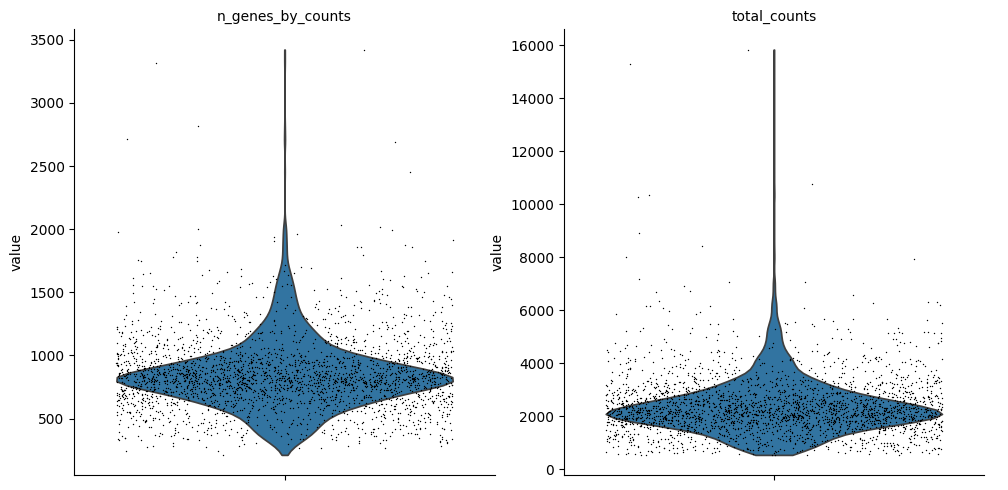

In [99]:
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts'],
    jitter=0.4,
    multi_panel=True
)

In [100]:
# Calculate percentage of mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    inplace=True
)

adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].head()

,n_genes_by_counts,total_counts,pct_counts_mt
index,,,
AAACATACAACCAC-1,781,2421.0,3.015283
AAACATTGAGCTAC-1,1352,4903.0,3.793596
AAACATTGATCAGC-1,1131,3149.0,0.889171
AAACCGTGCTTCCG-1,960,2639.0,1.743085
AAACCGTGTATGCG-1,522,981.0,1.223242


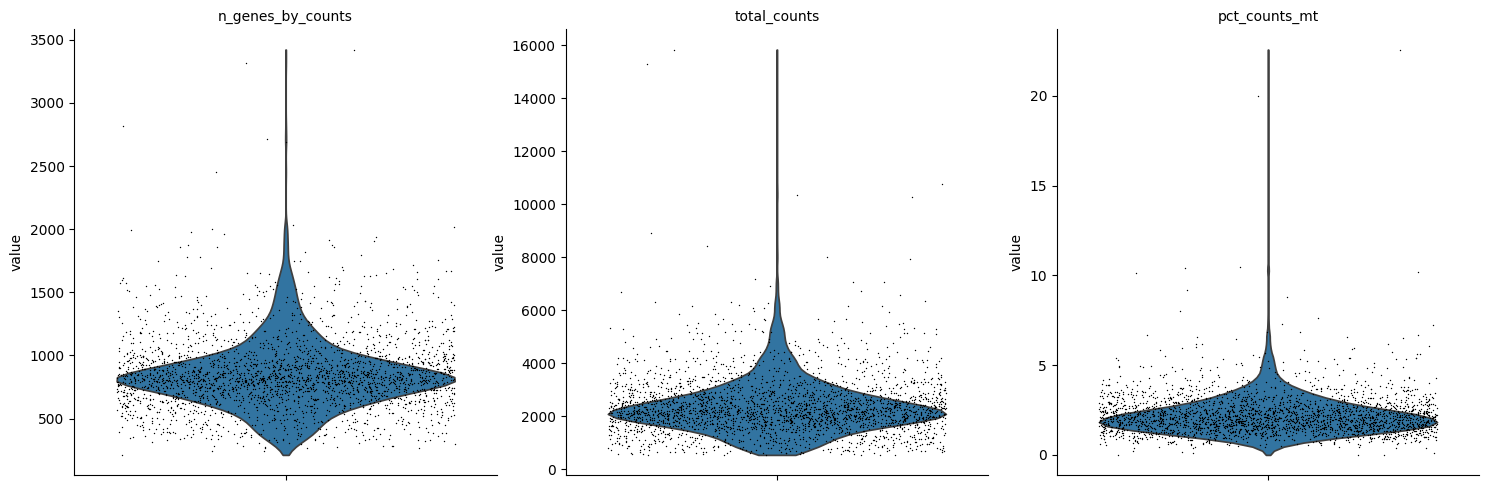

In [101]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

In [102]:
adata = adata[
    (adata.obs["n_genes_by_counts"] > 200) &
    (adata.obs["n_genes_by_counts"] < 2500) &
    (adata.obs["pct_counts_mt"] < 5)
].copy()

print("Cells after QC:", adata.n_obs)

Cells after QC: 2638


In [103]:
# Normalize each cell to the same total count
sc.pp.normalize_total(adata, target_sum=1e4)

# Log-transform the normalized expression values
sc.pp.log1p(adata)

# Preserve the normalized expression data for downstream marker analysis
adata.raw = adata

In [104]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor="seurat"
)

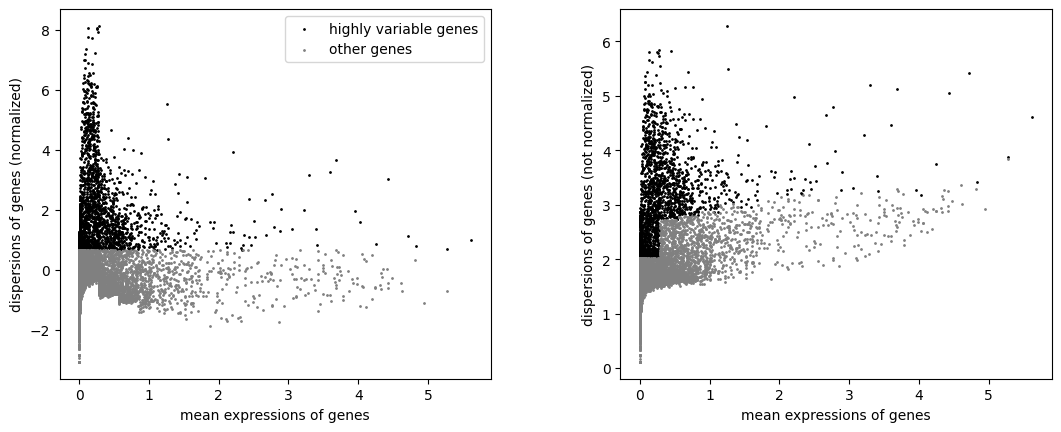

In [105]:
sc.pl.highly_variable_genes(adata)

/usr/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_1788/855627093.py:5: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(


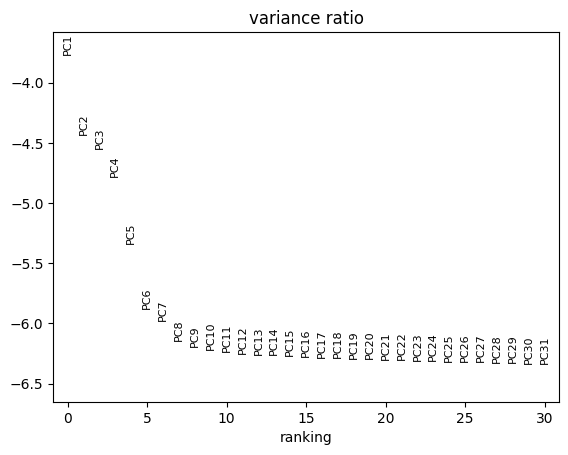

In [106]:
# Scale the highly variable genes
sc.pp.scale(adata, max_value=10)

# Perform PCA using the highly variable genes
sc.tl.pca(
    adata,
    use_highly_variable=True,
    svd_solver="arpack"
)

# Visualize variance explained by each principal component
sc.pl.pca_variance_ratio(adata, log=True)

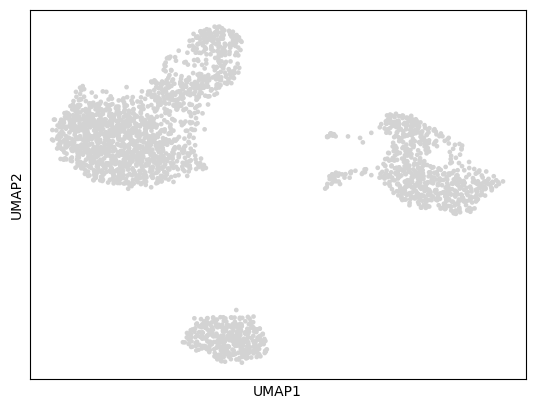

In [107]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=20)

sc.tl.umap(adata)

sc.pl.umap(adata)

In [108]:
!pip install leidenalg igraph

/tmp/ipykernel_1788/1580855064.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


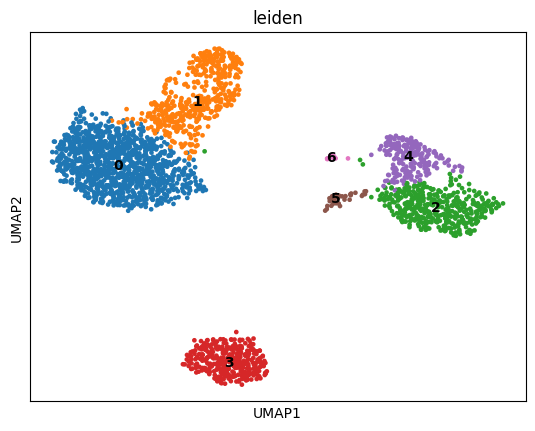

In [109]:
# Identify cell communities based on their neighborhood structure
sc.tl.leiden(
    adata,
    resolution=0.5
)

# Visualize the resulting clusters
sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data"
)

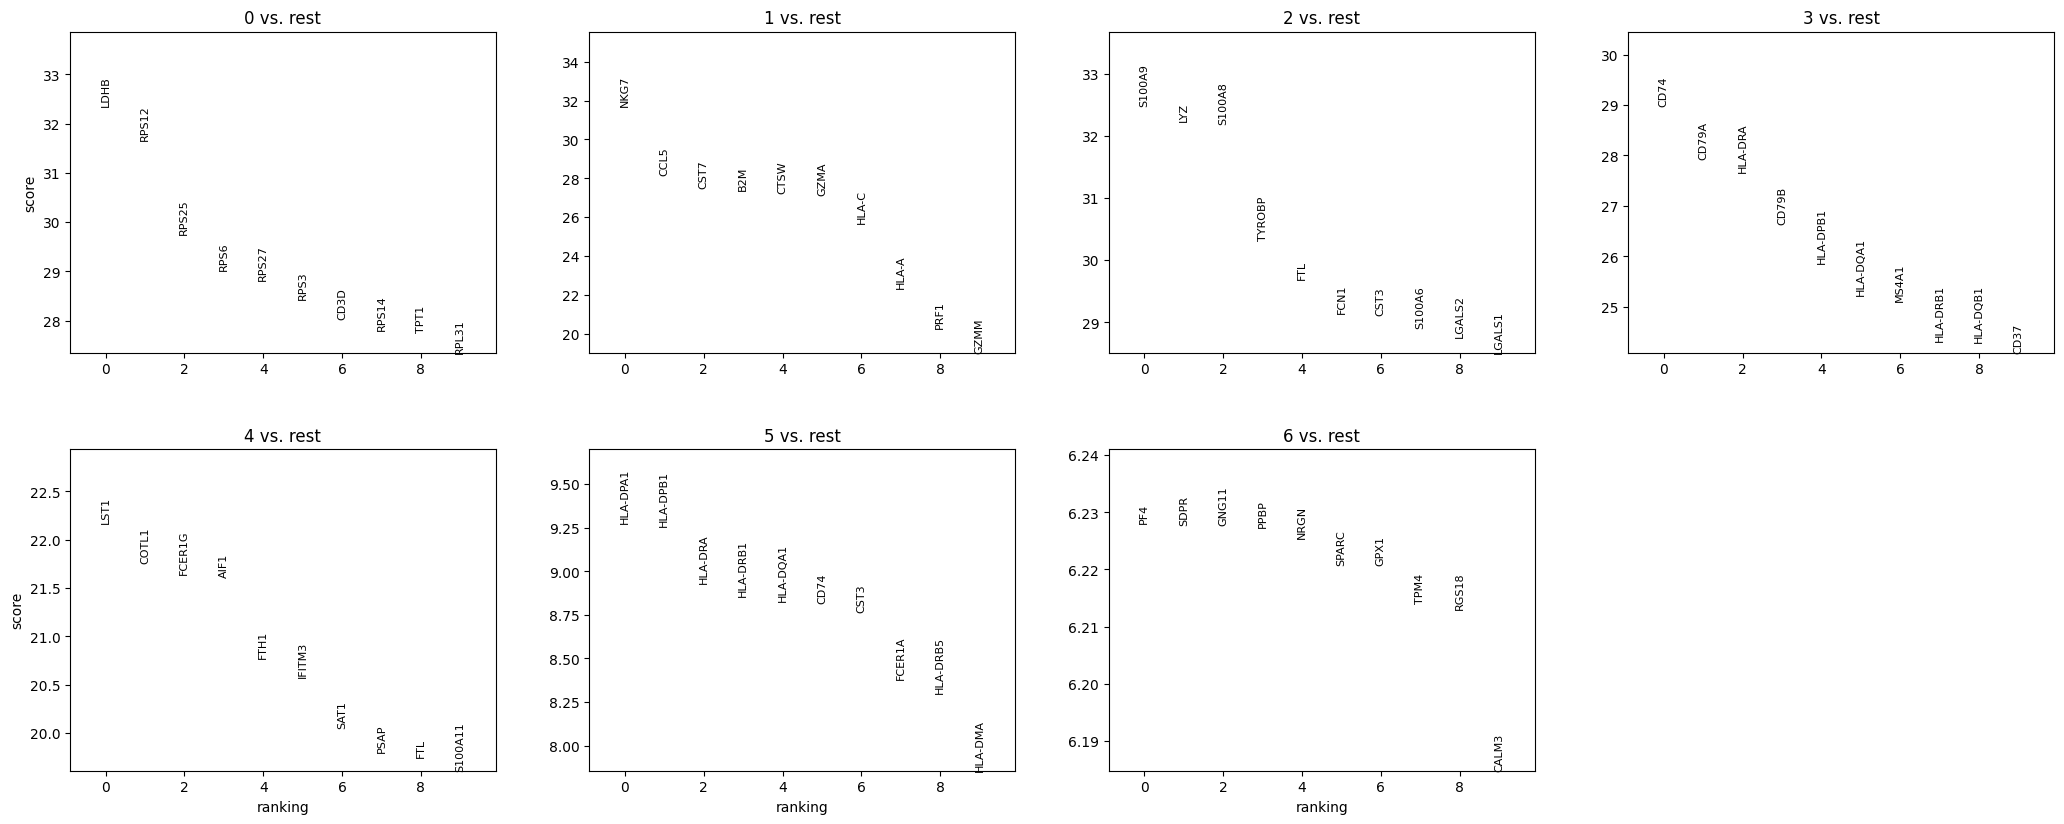

In [110]:
# Identify marker genes for each Leiden cluster
sc.tl.rank_genes_groups(
    adata,
    "leiden",
    method="wilcoxon"
)
# Extract marker genes into a dataframe
markers = sc.get.rank_genes_groups_df(
    adata,
    group=None
)
top_markers = (
    markers
    .sort_values(["group", "pvals_adj"])
    .groupby("group")
    .head(10)
)

top_markers
sc.pl.rank_genes_groups(
    adata,
    n_genes=10,
    sharey=False
)

In [111]:
# Show top marker genes for each cluster

markers = sc.get.rank_genes_groups_df(
    adata,
    group=None
)

markers.head(20)

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,LDHB,32.364609,2.731974,8.643853e-230,2.829825e-225
1,0,RPS12,31.653761,1.030539,6.731587e-220,1.101893e-215
2,0,RPS25,29.752140,1.148649,1.627058e-194,1.065333e-190
3,0,RPS6,29.020039,0.864711,3.676427e-185,1.719412e-181
4,0,RPS27,28.822777,1.001286,1.111941e-182,4.432503e-179
5,0,RPS3,28.441767,0.861576,6.160927e-178,2.016964e-174
6,0,CD3D,28.028463,3.201946,7.312246e-173,2.176257e-169
7,0,RPS14,27.811960,0.771258,3.109217e-170,8.482462e-167
8,0,TPT1,27.764036,0.958185,1.179614e-169,2.970630e-166
9,0,RPL31,27.342249,1.113318,1.335261e-164,2.732110e-161


In [112]:
top_markers = (
    markers
    .sort_values(["group", "pvals_adj"])
    .groupby("group")
    .head(10)
)

top_markers

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,LDHB,32.364609,2.731974,8.643853e-230,2.829825e-225
1,0,RPS12,31.653761,1.030539,6.731587e-220,1.101893e-215
32737,0,CD74,-31.309608,-2.821779,3.453161e-215,3.768320e-211
32736,0,CYBA,-30.978868,-2.091644,1.038327e-210,8.498191e-207
2,0,RPS25,29.752140,1.148649,1.627058e-194,1.065333e-190
...,...,...,...,...,...,...
196433,6,SPARC,6.220745,10.889243,4.947990e-10,1.850753e-06
196434,6,GPX1,6.220745,6.472116,4.947990e-10,1.850753e-06
196435,6,TPM4,6.214175,6.936467,5.159513e-10,1.850753e-06
196436,6,RGS18,6.213079,8.599377,5.195614e-10,1.850753e-06


In [113]:
sc.tl.rank_genes_groups(
    adata,
    "leiden",
    method="wilcoxon"
)

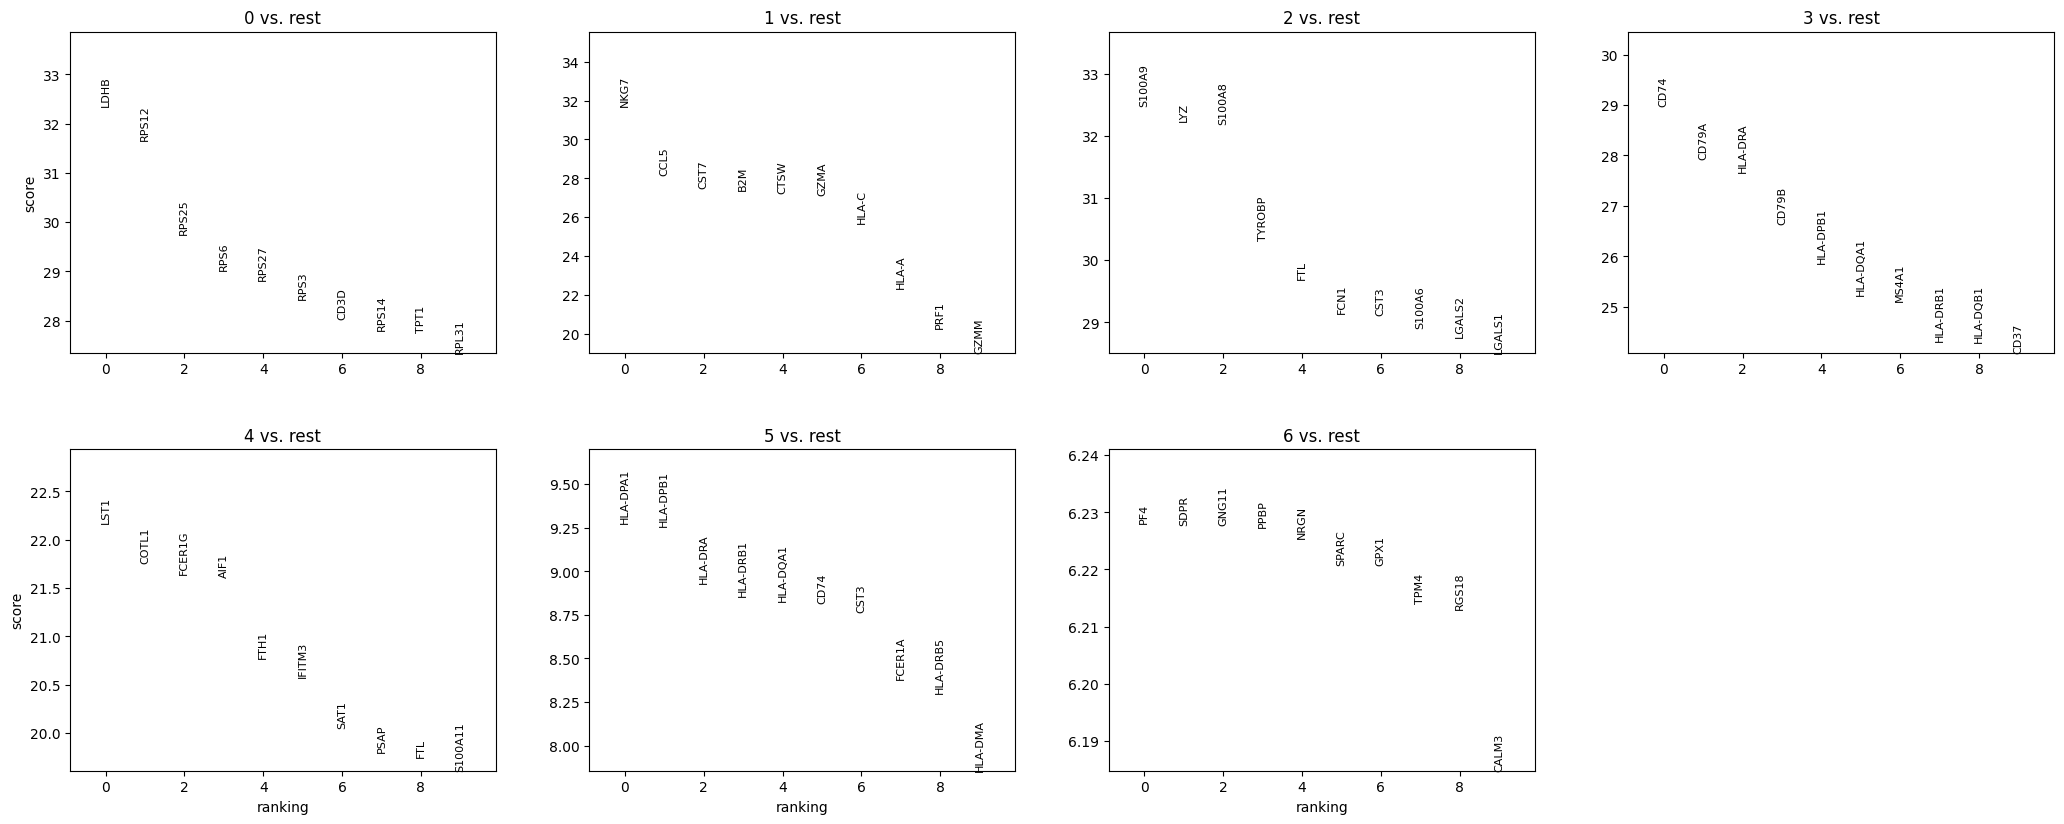

In [114]:
sc.pl.rank_genes_groups(
    adata,
    n_genes=10,
    sharey=False
)

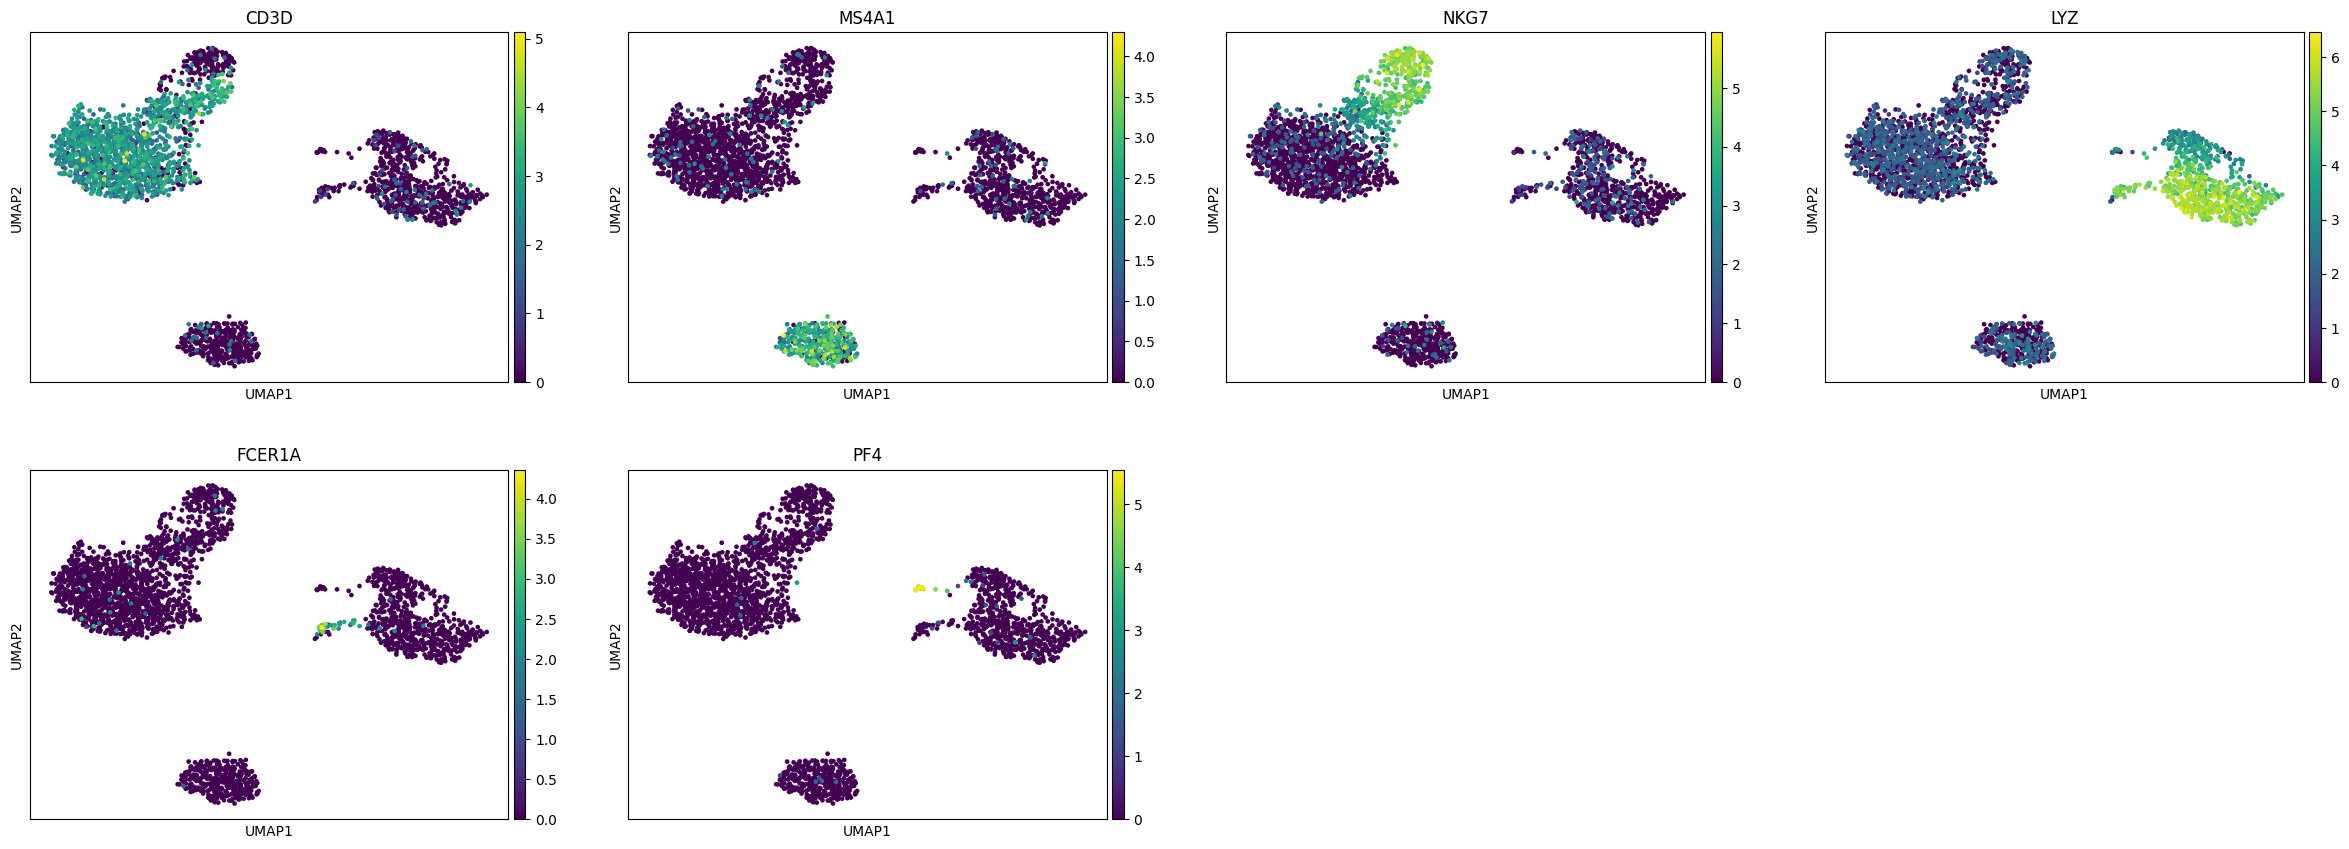

In [115]:
sc.pl.umap(
    adata,
    color=["CD3D", "MS4A1", "NKG7", "LYZ", "FCER1A", "PF4"]
)

In [116]:
marker_genes = {
    "T cells": ["CD3D", "CD3E", "TRBC1"],
    "NK cells": ["NKG7", "GNLY", "CCL5"],
    "B cells": ["MS4A1", "CD79A", "CD74"],
    "Monocytes": ["LYZ", "S100A8", "S100A9"],
    "Dendritic cells": ["FCER1A", "CST3", "HLA-DRA"],
    "Megakaryocytes": ["PF4", "PPBP", "RGS18"]
}

# Keep only genes that are actually present in the dataset
marker_genes_present = {
    cell_type: [gene for gene in genes if gene in adata.var_names]
    for cell_type, genes in marker_genes.items()
}

marker_genes_present

{'T cells': ['CD3D', 'CD3E'],
 'NK cells': ['NKG7', 'GNLY', 'CCL5'],
 'B cells': ['MS4A1', 'CD79A', 'CD74'],
 'Monocytes': ['LYZ', 'S100A8', 'S100A9'],
 'Dendritic cells': ['FCER1A', 'CST3', 'HLA-DRA'],
 'Megakaryocytes': ['PF4', 'PPBP', 'RGS18']}

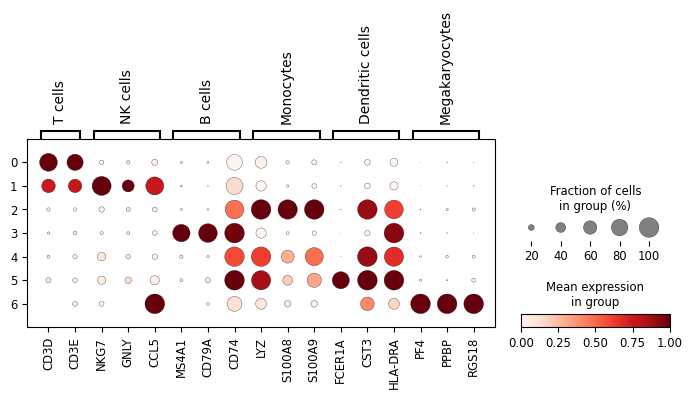

In [117]:
sc.pl.dotplot(
    adata,
    marker_genes_present,
    groupby="leiden",
    standard_scale="var"
)

In [118]:
markers = sc.get.rank_genes_groups_df(
    adata,
    group=None
)

markers.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,LDHB,32.364609,2.731974,8.643853e-230,2.829825e-225
1,0,RPS12,31.653761,1.030539,6.731587e-220,1.101893e-215
2,0,RPS25,29.752140,1.148649,1.627058e-194,1.065333e-190
3,0,RPS6,29.020039,0.864711,3.676427e-185,1.719412e-181
4,0,RPS27,28.822777,1.001286,1.111941e-182,4.432503e-179


In [119]:
cluster_4_markers = (
    markers[markers["group"] == "4"]
    .sort_values("pvals_adj")
    .head(20)
)

cluster_4_markers[["names", "scores", "logfoldchanges", "pvals_adj"]]

,names,scores,logfoldchanges,pvals_adj
130952,LST1,22.167772,5.125140,2.301638e-104
130953,COTL1,21.758028,3.672393,9.492055e-101
130954,FCER1G,21.644463,4.767775,7.479223e-100
130955,AIF1,21.611677,4.866640,1.141626e-99
130956,FTH1,20.778624,2.936078,4.424147e-92
130957,IFITM3,20.579256,4.893732,2.297650e-90
130958,SAT1,20.054546,3.558698,8.615532e-86
130959,PSAP,19.806797,3.439036,1.064434e-83
130960,FTL,19.749001,3.183708,2.976255e-83
130961,S100A11,19.610956,3.391719,4.081390e-82


In [120]:
for cluster in ["2", "4"]:
    print(f"\nCluster {cluster}")
    display(
        markers[markers["group"] == cluster]
        .sort_values("pvals_adj")
        .head(15)[["names", "scores", "logfoldchanges", "pvals_adj"]]
    )


Cluster 2


,names,scores,logfoldchanges,pvals_adj
65476,S100A9,32.488300,7.356833,5.107114e-227
65477,LYZ,32.236744,6.112550,8.833605e-224
65478,S100A8,32.196529,7.554184,2.153966e-223
65479,TYROBP,30.317032,5.346274,5.595953e-198
65480,FTL,29.689404,3.416926,6.889443e-190
65481,FCN1,29.141275,5.358047,5.879635e-183
65482,CST3,29.108187,5.490592,1.322602e-182
65483,S100A6,28.902494,2.942224,4.545651e-180
65484,LGALS2,28.754072,6.195984,2.930216e-178
98213,MALAT1,-28.541529,-1.579732,1.171486e-175



Cluster 4


,names,scores,logfoldchanges,pvals_adj
130952,LST1,22.167772,5.125140,2.301638e-104
130953,COTL1,21.758028,3.672393,9.492055e-101
130954,FCER1G,21.644463,4.767775,7.479223e-100
130955,AIF1,21.611677,4.866640,1.141626e-99
130956,FTH1,20.778624,2.936078,4.424147e-92
130957,IFITM3,20.579256,4.893732,2.297650e-90
130958,SAT1,20.054546,3.558698,8.615532e-86
130959,PSAP,19.806797,3.439036,1.064434e-83
130960,FTL,19.749001,3.183708,2.976255e-83
130961,S100A11,19.610956,3.391719,4.081390e-82


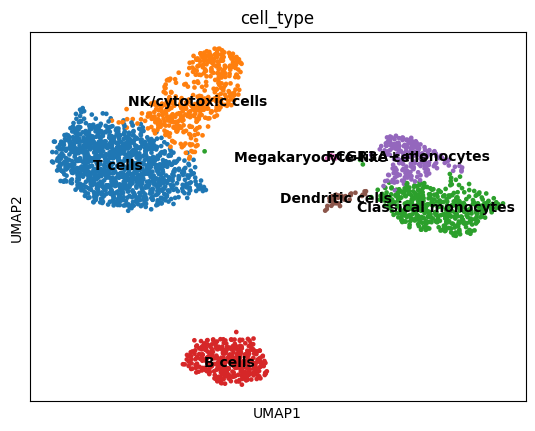

In [124]:
# Assign biological cell-type labels to each Leiden cluster
adata.obs["cell_type"] = adata.obs["leiden"].map({
    "0": "T cells",
    "1": "NK/cytotoxic cells",
    "2": "Classical monocytes",
    "3": "B cells",
    "4": "FCGR3A+ monocytes",
    "5": "Dendritic cells",
    "6": "Megakaryocyte-like cells"
})

# Visualize the annotated cell populations
sc.pl.umap(
    adata,
    color="cell_type",
    legend_loc="on data"
)

In [122]:
adata.obs["cell_type"].value_counts()

cell_type
T cells                     1143
NK/cytotoxic cells           461
Classical monocytes          441
B cells                      345
FCGR3A+ monocytes            200
Dendritic cells               35
Megakaryocyte-like cells      13
Name: count, dtype: int64

In [123]:
cell_counts = adata.obs["cell_type"].value_counts()

cell_percentages = (
    cell_counts / cell_counts.sum() * 100
).round(2)

cell_percentages

cell_type
T cells                     43.33
NK/cytotoxic cells          17.48
Classical monocytes         16.72
B cells                     13.08
FCGR3A+ monocytes            7.58
Dendritic cells              1.33
Megakaryocyte-like cells     0.49
Name: count, dtype: float64

## Biological Interpretation

Single-cell RNA-seq analysis identified seven major cell populations within the PBMC dataset based on cluster-specific gene-expression patterns.

The major populations identified were:

- **T cells** – supported by markers such as CD3D and CD3E.
- **NK/cytotoxic cells** – characterized by NKG7, GNLY, and CCL5.
- **Classical monocytes** – characterized by S100A8, S100A9, LYZ, and FCN1.
- **B cells** – supported by MS4A1, CD79A, and CD74.
- **FCGR3A+ monocytes** – characterized by FCGR3A, LST1, FCER1G, AIF1, and CST3.
- **Dendritic cells** – supported by FCER1A, HLA-DRA, and CST3.
- **Megakaryocyte-like cells** – characterized by PF4, PPBP, and RGS18.

T cells represented the largest population, followed by NK/cytotoxic cells, classical monocytes, B cells, and FCGR3A+ monocytes. Dendritic cells and megakaryocyte-like cells represented smaller populations.

The distinction between classical and FCGR3A+ monocytes demonstrates heterogeneity within the myeloid compartment. These cell identities were assigned based on patterns of marker-gene expression rather than individual genes alone.

### Limitations

Cell-type annotations in this analysis are working annotations based on marker-gene expression. More detailed annotation methods and additional biological validation would be required to establish definitive cell identities.

## Conclusion

This analysis demonstrates a complete single-cell RNA-seq workflow for identifying immune-cell populations in peripheral blood. Using the PBMC3k dataset, quality control, normalization, highly variable gene selection, PCA, UMAP, Leiden clustering, and marker-gene analysis were used to identify seven major cell populations.

The analysis highlights the heterogeneity of PBMCs and demonstrates how gene-expression patterns can be used to distinguish lymphoid and myeloid populations, including different monocyte subtypes.

This project provided practical experience with single-cell RNA-seq data analysis using Python and Scanpy and established a foundation for applying similar computational approaches to more complex disease and tumor-immune datasets.